<!--nav-->
> **Обучающая цепочка · 7/8.**  ·  ← [предыдущий](06_theory_comparison.ipynb)  ·  [следующий](08_stamp_two_plates.ipynb) →  
> *Чему учит:* единая параметрическая модель, морфинг теорий, нелинейный контакт МОР+КТН.

# 07 — Единая модель, морфинг теорий и нелинейный контакт (v0.6.0)

Архитектурный стержень версии — **одна параметрическая модель**
(`theory.TheoryParams` + решатель `ktn_solver.KTNSolver`): все четыре теории суть
именованные ПРЕСЕТЫ параметров ОДНОГО решателя полной КТН, а редукции точны ПО
ПОСТРОЕНИЮ (тот же путь исполнения), а не «совпадением до машинной точности».

* **§1. Решётка 2×2** — `classic` / `karman` / `ktn_linear` / `ktn_full` одним
  решателем (две оси: геометрическая нелинейность × уточнение сдвига/обжатия).
* **§2. Морфинг** — непрерывная крутилка `refinement_scale` α: из полной КТН
  (α=1) плавно в Карман (α=0); «одна теория с крутилкой».
* **§3. Нелинейный контакт МОР+КТН** — метод обобщённой реакции ВОКРУГ полного
  нелинейного решателя КТН; контакт «щупает» ЛИЦЕВУЮ поверхность (условие
  Синьорини `u_c = w + (h_c²−h_*²)Δw ≤ z`). Подпись теории — в зоне и пике реакции.
* **§4. Диагностика зоны** — размер, доля площади, пик, суммарная сила, ЧИСЛО
  связных пятен (`diagnostics.contact_report`).

Каноническая пластина — защемлённый круг, неподвижная кромка. Толстая (`h/L=0.2`),
чтобы поправки уточнения `O((h/L)²)` были видны. Case-файл единой модели:
`cases/ci/ktn_full_circle_clamped_uniform.toml`.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.tri import Triangulation

from plate_solver import theory
from plate_solver.config import Config
from plate_solver.contact_nl import NonlinearContactMOR
from plate_solver.diagnostics import contact_report
from plate_solver.geometry import make_circle
from plate_solver.ktn_solver import KTNSolver

nu, h = 0.3, 0.2
dom = make_circle(1.0)
NAMES = ["classic", "karman", "ktn_linear", "ktn_full"]
STYLE = {"classic": ("o--", "tab:blue"), "karman": ("s-", "tab:red"),
         "ktn_linear": ("^-.", "tab:orange"), "ktn_full": ("x:", "tab:green")}


def cfg(q0=0.01, Q=72, **kw):
    base = dict(E=1.0, h=h, nu=nu, a=1.0, q0=q0, p=10, Q=Q,
                n_load_steps=3, karman_tol=1e-6, karman_max_iter=200)
    base.update(kw)
    return Config(**base)


def solver(name, c, hh=None):
    cc = c if hh is None else cfg(q0=c.q0, Q=c.Q, h=hh, p=c.p)
    return KTNSolver.from_theory_name(dom, cc, name, bc_type="clamped",
                                      inplane_bc="immovable")

## 1. Единая модель: решётка 2×2 одним решателем

Две управляющие оси (`theory.TheoryParams`): флаг `membrane` (геометрическая
нелинейность, член `L(Φ,w)`) и параметры толщины `h_ψ², h_*²` (уточнение
сдвига/обжатия). Их комбинации дают решётку:

|                   | уточнение ВЫКЛ | уточнение ВКЛ |
|-------------------|----------------|---------------|
| нелинейность ВЫКЛ | `classic`      | `ktn_linear`  |
| нелинейность ВКЛ  | `karman`       | `ktn_full`    |

Один и тот же `KTNSolver` конфигурируется пресетом — ниже видно, чем пресеты
различаются (`solve_ktn_terms` — активны ли КТН-члены в РЕШЕНИИ, `face_curv_coeff`
— масштаб лицевой кривизны для контакта).

In [2]:
c = cfg()
sol = {n: solver(n, c) for n in NAMES}
res = {n: sol[n].solve_uniform() for n in NAMES}
wmax = {n: res[n].w_max for n in NAMES}

print("параметры пресетов (одна модель, разные точки):")
print(f"{'теория':<11} {'membrane':>9} {'solve_ktn':>10} {'face_curv':>11}")
for n in NAMES:
    p = sol[n].params
    print(f"{n:<11} {str(p.membrane):>9} {str(p.solve_ktn_terms):>10} {p.face_curv_coeff:>11.3e}")

print("\nсрединный прогиб w_max (решётка 2×2):")
print(f"{'':<14}{'уточн. ВЫКЛ':>14}{'уточн. ВКЛ':>16}")
print(f"{'нелин. ВЫКЛ':<14}{wmax['classic']:>14.6f}   ktn_linear {wmax['ktn_linear']:.6f}")
print(f"{'нелин. ВКЛ':<14}{wmax['karman']:>14.6f}   ktn_full   {wmax['ktn_full']:.6f}")

параметры пресетов (одна модель, разные точки):
теория       membrane  solve_ktn   face_curv
classic         False      False   0.000e+00
karman           True      False   0.000e+00
ktn_linear      False      False  -5.238e-03
ktn_full         True       True  -5.238e-03

срединный прогиб w_max (решётка 2×2):
                 уточн. ВЫКЛ      уточн. ВКЛ
нелин. ВЫКЛ         0.210947   ktn_linear 0.210947
нелин. ВКЛ          0.157046   ktn_full   0.153541


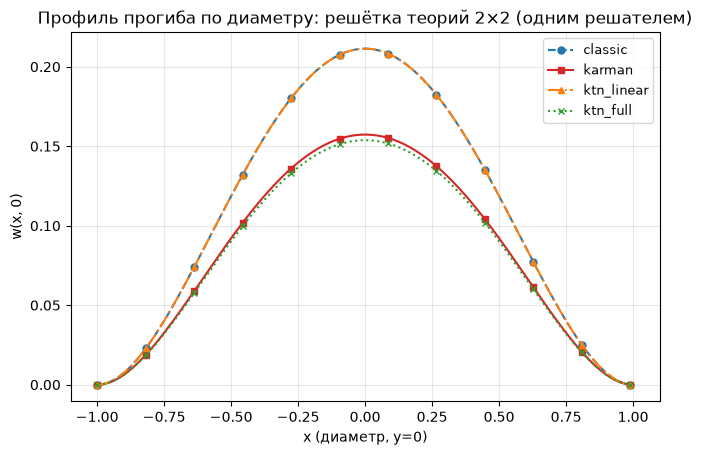

classic — самый жёсткий (мал прогиб не даёт мембранного ужестчения); karman/ktn — нелинейные; ktn мягче за счёт сдвига/обжатия


In [3]:
xs = np.linspace(-0.999, 0.999, 200)
ys = np.zeros_like(xs)
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for n in NAMES:
    w = sol[n].deflection(res[n].cw, xs, ys)
    ls, col = STYLE[n]
    ax.plot(xs, w, ls, color=col, ms=5, markevery=18, label=n)
ax.set_xlabel("x (диаметр, y=0)")
ax.set_ylabel("w(x, 0)")
ax.set_title("Профиль прогиба по диаметру: решётка теорий 2×2 (одним решателем)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()
print("classic — самый жёсткий (мал прогиб не даёт мембранного ужестчения); "
      "karman/ktn — нелинейные; ktn мягче за счёт сдвига/обжатия")

## 2. Морфинг: одна теория с крутилкой α (Карман ↔ полная КТН)

`refinement_scale` α масштабирует уточнение (`h_ψ²→α h_ψ²`, `h_*²→α h_*²`): α=0 —
Карман (уточнение снято), α=1 — полная КТН, плавно между. Концы морфинга ТОЧНО
совпадают с пресетами `karman`/`ktn_full` (единая модель, усиление T6). Чтобы
эффект был виден в СРЕДИННОМ прогибе под равномерной нагрузкой, берём ТОЛСТУЮ
пластину (`h/L=0.6`): поправка КТН `O((h/L)²)` тогда велика.

α=0: |wm−karman|/karman   = 0.00e+00  (машинный ноль ⇒ точная редукция)
α=1: |wm−ktn_full|/ktn_full = 0.00e+00


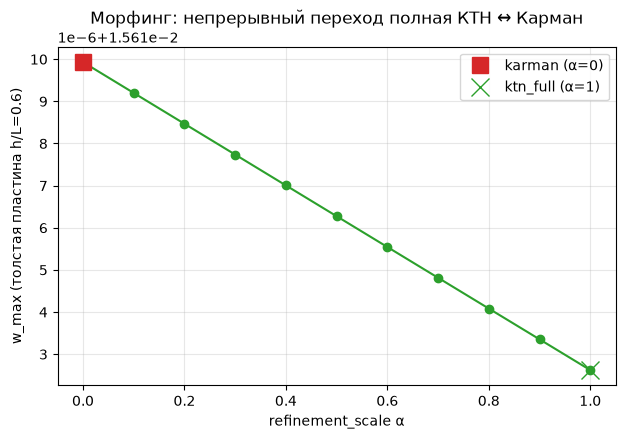

In [4]:
h_thick = 0.6
c_thick = cfg(q0=0.02, h=h_thick)
alphas = np.linspace(0.0, 1.0, 11)
wm = []
for a in alphas:
    p = theory.ktn_full(nu, h_thick).with_refinement_scale(a)
    s = KTNSolver.from_config(dom, c_thick, p, bc_type="clamped", inplane_bc="immovable")
    wm.append(s.solve_uniform().w_max)
wm = np.array(wm)

# концы морфинга ТОЧНО = пресеты (редукция по построению)
w_k = solver("karman", c_thick, hh=h_thick).solve_uniform().w_max
w_f = solver("ktn_full", c_thick, hh=h_thick).solve_uniform().w_max
print(f"α=0: |wm−karman|/karman   = {abs(wm[0]-w_k)/w_k:.2e}  (машинный ноль ⇒ точная редукция)")
print(f"α=1: |wm−ktn_full|/ktn_full = {abs(wm[-1]-w_f)/w_f:.2e}")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(alphas, wm, "o-", color="tab:green")
ax.plot(0.0, w_k, "s", color="tab:red", ms=11, label="karman (α=0)")
ax.plot(1.0, w_f, "x", color="tab:green", ms=13, label="ktn_full (α=1)")
ax.set_xlabel("refinement_scale α")
ax.set_ylabel("w_max (толстая пластина h/L=0.6)")
ax.set_title("Морфинг: непрерывный переход полная КТН ↔ Карман")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 3. Нелинейный контакт МОР+КТН: подпись теории в зоне контакта

Метод обобщённой реакции (МОР) ВОКРУГ полного нелинейного решателя КТН (связка,
которой в литературе нет). Контакт «щупает» ЛИЦЕВУЮ поверхность:

$$u_c = w + (h_c^2 - h_*^2)\,\Delta w \le z,$$

где `z` — зазор до жёсткого основания. Коэффициент кривизны `(h_c²−h_*²)`
масштабируется теорией (`TheoryParams.face_curv_coeff`): для `karman` он НОЛЬ
(контакт по срединной, `u_c=w`), для полной КТН — лицевая кривизна. Отсюда
ПОДПИСЬ КТН: при одинаковом зазоре зона и пик реакции у `ktn_full` иные, чем у
`karman`. Схема — совмещённая (`merged`, быстрая; предмет T7).

In [5]:
cc = cfg(q0=0.01, Q=64, beta=1.5, max_iter=800, tol=3e-4)


def run_contact(name, frac=0.5):
    s = solver(name, cc)
    gap = frac * s.solve_uniform().w_max
    r = NonlinearContactMOR(s, cc, gap=gap, scheme="merged").solve()
    rep = contact_report(r.r_nodes, s.quad)
    return s, r, rep, gap


sk, rk, repk, gk = run_contact("karman")
sf, rf, repf, gf = run_contact("ktn_full")

print(f"{'теория':<10}{'зазор z':>10}{'n_contact':>11}{'пятен':>7}{'r_max':>11}{'∑r dA':>11}")
for nm, rep in (("karman", repk), ("ktn_full", repf)):
    print(f"{nm:<10}{(gk if nm=='karman' else gf):>10.4f}{rep['n_contact']:>11}"
          f"{rep['n_components']:>7}{rep['r_max']:>11.4e}{rep['r_total']:>11.4e}")
d_peak = abs(repf['r_max'] - repk['r_max']) / repk['r_max']
print(f"\nподпись КТН: пик реакции отличается на {d_peak*100:.1f}% "
      f"(лицевая кривизна сглаживает/смещает контакт)")

теория       зазор z  n_contact  пятен      r_max      ∑r dA
karman        0.0784         68      1 4.4180e-02 5.0630e-03
ktn_full      0.0767         84      1 4.1307e-02 5.3898e-03

подпись КТН: пик реакции отличается на 6.5% (лицевая кривизна сглаживает/смещает контакт)


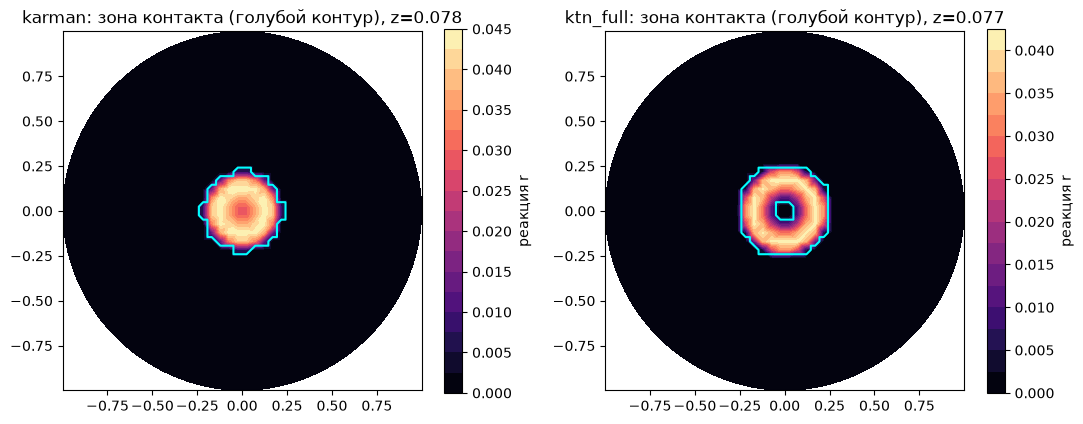

голубой контур — граница зоны контакта (r>0); поле — обобщённая реакция r≥0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
panels = (("karman", sk, rk, gk), ("ktn_full", sf, rf, gf))
for ax, (nm, s, r, gap) in zip(axes, panels, strict=True):
    tri = Triangulation(s.quad.x, s.quad.y)
    cs = ax.tricontourf(tri, r.r_nodes, levels=18, cmap="magma")
    ax.tricontour(tri, r.contact_mask.astype(float), levels=[0.5],
                  colors="cyan", linewidths=1.5)
    fig.colorbar(cs, ax=ax, shrink=0.85, label="реакция r")
    ax.set_aspect("equal")
    ax.set_title(f"{nm}: зона контакта (голубой контур), z={gap:.3f}")
plt.tight_layout()
plt.show()
print("голубой контур — граница зоны контакта (r>0); поле — обобщённая реакция r≥0")

### 3-бис. Диагностика зоны: профиль реакции и лицевые напряжения (§8)

Зона контакта — первым классом: помимо карты реакции (выше) — РАДИАЛЬНЫЙ профиль
`r(ρ)` (реакция сосредоточена в кольце у границы зоны, а не в центре) и ЛИЦЕВЫЕ
изгибные напряжения `σ_vm` (индикатор концентраций, сглаженных уточнённой
теорией). Полная сводка — `diagnostics.contact_report`.

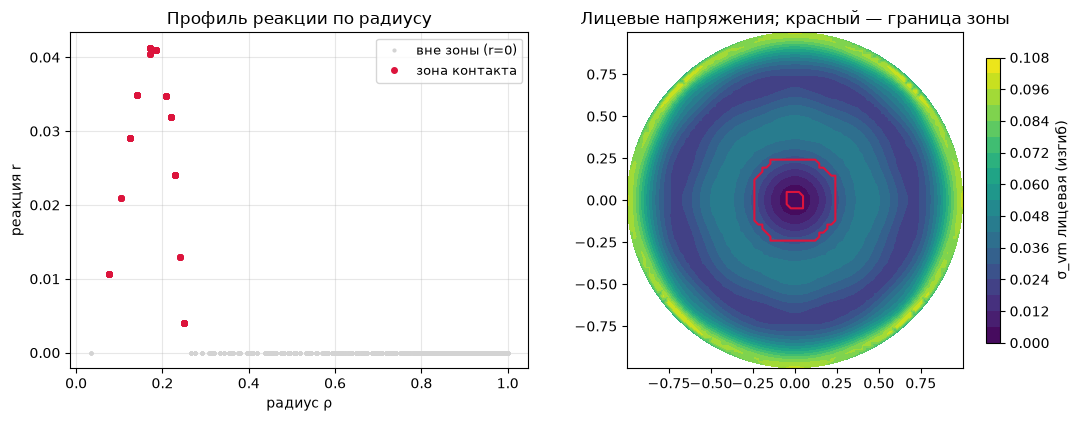

пик лицевого σ_vm в зоне: 2.791e-02; сводка зоны: узлов=84, пятен=1, ∑r=5.390e-03


In [7]:
qx, qy = sf.quad.x, sf.quad.y
rho = np.hypot(qx, qy)
Mx, My, Mxy = sf.moments_at(rf.cw, qx, qy)
sig_vm = 6.0 / h**2 * np.sqrt(Mx**2 - Mx * My + My**2 + 3.0 * Mxy**2)   # лицевое (изгиб)
mask = rf.contact_mask

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))
axL.plot(rho[~mask], rf.r_nodes[~mask], ".", color="lightgray", ms=4, label="вне зоны (r=0)")
axL.plot(rho[mask], rf.r_nodes[mask], "o", color="crimson", ms=4, label="зона контакта")
axL.set_xlabel("радиус ρ")
axL.set_ylabel("реакция r")
axL.set_title("Профиль реакции по радиусу")
axL.legend(fontsize=9)
axL.grid(alpha=0.3)

tri = Triangulation(qx, qy)
cs = axR.tricontourf(tri, sig_vm, levels=18, cmap="viridis")
axR.tricontour(tri, mask.astype(float), levels=[0.5], colors="crimson", linewidths=1.5)
fig.colorbar(cs, ax=axR, shrink=0.85, label="σ_vm лицевая (изгиб)")
axR.set_aspect("equal")
axR.set_title("Лицевые напряжения; красный — граница зоны")
plt.tight_layout()
plt.show()
rep = contact_report(rf.r_nodes, sf.quad)
print(f"пик лицевого σ_vm в зоне: {np.max(sig_vm[mask]):.3e}; сводка зоны: "
      f"узлов={rep['n_contact']}, пятен={rep['n_components']}, ∑r={rep['r_total']:.3e}")

## 4. Редукции точны ПО ПОСТРОЕНИЮ (атлас различий)

Единая модель делает редукции не «совпадением до допуска», а тождеством ПУТИ
исполнения (усиление теоремы T6):

| Редукция | Как включается | Что получаем |
|---|---|---|
| контакт ВЫКЛ (`z→∞`, `r≡0`) | нет активной реакции | свободный решатель КТН (v0.5) |
| нелинейность ВЫКЛ (`membrane=False`) | нет члена `L(Φ,w)` | линейный МОР по бигармонике |
| уточнение ВЫКЛ (`α→0`) | `h_ψ²=h_*²=0` | кармановский контакт (`u_c=w`) |

Ниже — контроль на параметрах (без тяжёлых прогонов): у `karman` лицевой
коэффициент НОЛЬ (контакт по срединной), у `ktn_full` — физическая лицевая
кривизна; морфинг α=0 снимает КТН-члены в РЕШЕНИИ (тот же путь, что Карман).

In [8]:
pf = theory.ktn_full(nu, h)
pk = theory.karman()
p0 = theory.ktn_full(nu, h).with_refinement_scale(0.0)   # α=0
print(f"karman  : face_curv_coeff = {pk.face_curv_coeff:.3e}  (0 ⇒ контакт по срединной u_c=w)")
print(f"ktn_full: face_curv_coeff = {pf.face_curv_coeff:.3e}  (лицевая кривизна ⇒ подпись КТН)")
print(f"морфинг α=0: solve_ktn_terms = {p0.solve_ktn_terms}  "
      f"(КТН-члены сняты ⇒ путь решения = Карман)")
assert pk.face_curv_coeff == 0.0 and pf.face_curv_coeff != 0.0
assert p0.solve_ktn_terms is False
print("\nвсе редукции согласованы (единая модель §3, гейты R1/R3/R6)")

karman  : face_curv_coeff = 0.000e+00  (0 ⇒ контакт по срединной u_c=w)
ktn_full: face_curv_coeff = -5.238e-03  (лицевая кривизна ⇒ подпись КТН)
морфинг α=0: solve_ktn_terms = False  (КТН-члены сняты ⇒ путь решения = Карман)

все редукции согласованы (единая модель §3, гейты R1/R3/R6)


## 5. Итог

Версия v0.6.0 связывает три линии в один инструмент:

1. **единая параметрическая модель** — четыре теории как пресеты одного решателя,
   редукции точны по построению (`theory.py`, `ktn_solver.py`);
2. **нелинейный контакт МОР+КТН** — метод обобщённой реакции вокруг полной КТН с
   лицевым условием Синьорини; вложенная схема — эталон, совмещённая (T7) — рабочая
   (`contact_nl.py`);
3. **диагностика зоны контакта** — размер, пик, суммарная сила и топология
   (число связных пятен) первым классом (`diagnostics.py`).

**Оговорки.** Контакт реализован на защемлённой односвязной пластине; лицевые
алгебраические поправки `O(h²)` (`κ_q q`, `κ_r D r`) опущены (сохранён
доминирующий кривизный член). Совмещённая схема сходится при малости
нагрузки/зазора (T7); при сильной нелинейности надёжнее вложенная (`scheme="nested"`).
Маршрутизация контакта через case-файлы (`[model] theory` + препятствие) —
направление развития следующей версии.